In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import warnings

In [3]:
# For better visualizations
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Load dataset
titanic = pd.read_csv('train.csv')
display(titanic)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


# Exploratory Data Analysis
---

In [5]:
# Create a copy
titanic_eda = titanic.copy()

In [6]:
# Check summary statistics for numerical variables
titanic_eda.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [7]:
#Summary statistics for categorical variable "HomePlanet"
titanic_eda['HomePlanet'].value_counts(normalize=True)

,proportion
HomePlanet,
Earth,0.541922
Europa,0.250942
Mars,0.207136


In [8]:
#Summary statistics for categorical variable "CryoSleep"
titanic_eda['CryoSleep'].value_counts(normalize=True)

,proportion
CryoSleep,
False,0.641694
True,0.358306


In [9]:
#Summary statistics for categorical variable "Destination"
titanic_eda['Destination'].value_counts(normalize=True)

,proportion
Destination,
TRAPPIST-1e,0.694983
55 Cancri e,0.211491
PSO J318.5-22,0.093526


In [10]:
#Summary statistics for categorical variable "VIP"
titanic_eda['VIP'].value_counts(normalize=True)

,proportion
VIP,
False,0.976561
True,0.023439


In [11]:
#Summary statistics for categorical variable "Transported"
titanic_eda['Transported'].value_counts(normalize=True)

,proportion
Transported,
True,0.503624
False,0.496376


In [12]:
# Checking missing values
titanic_eda.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [13]:
# Checking duplicates
titanic_eda.duplicated().sum()

np.int64(0)

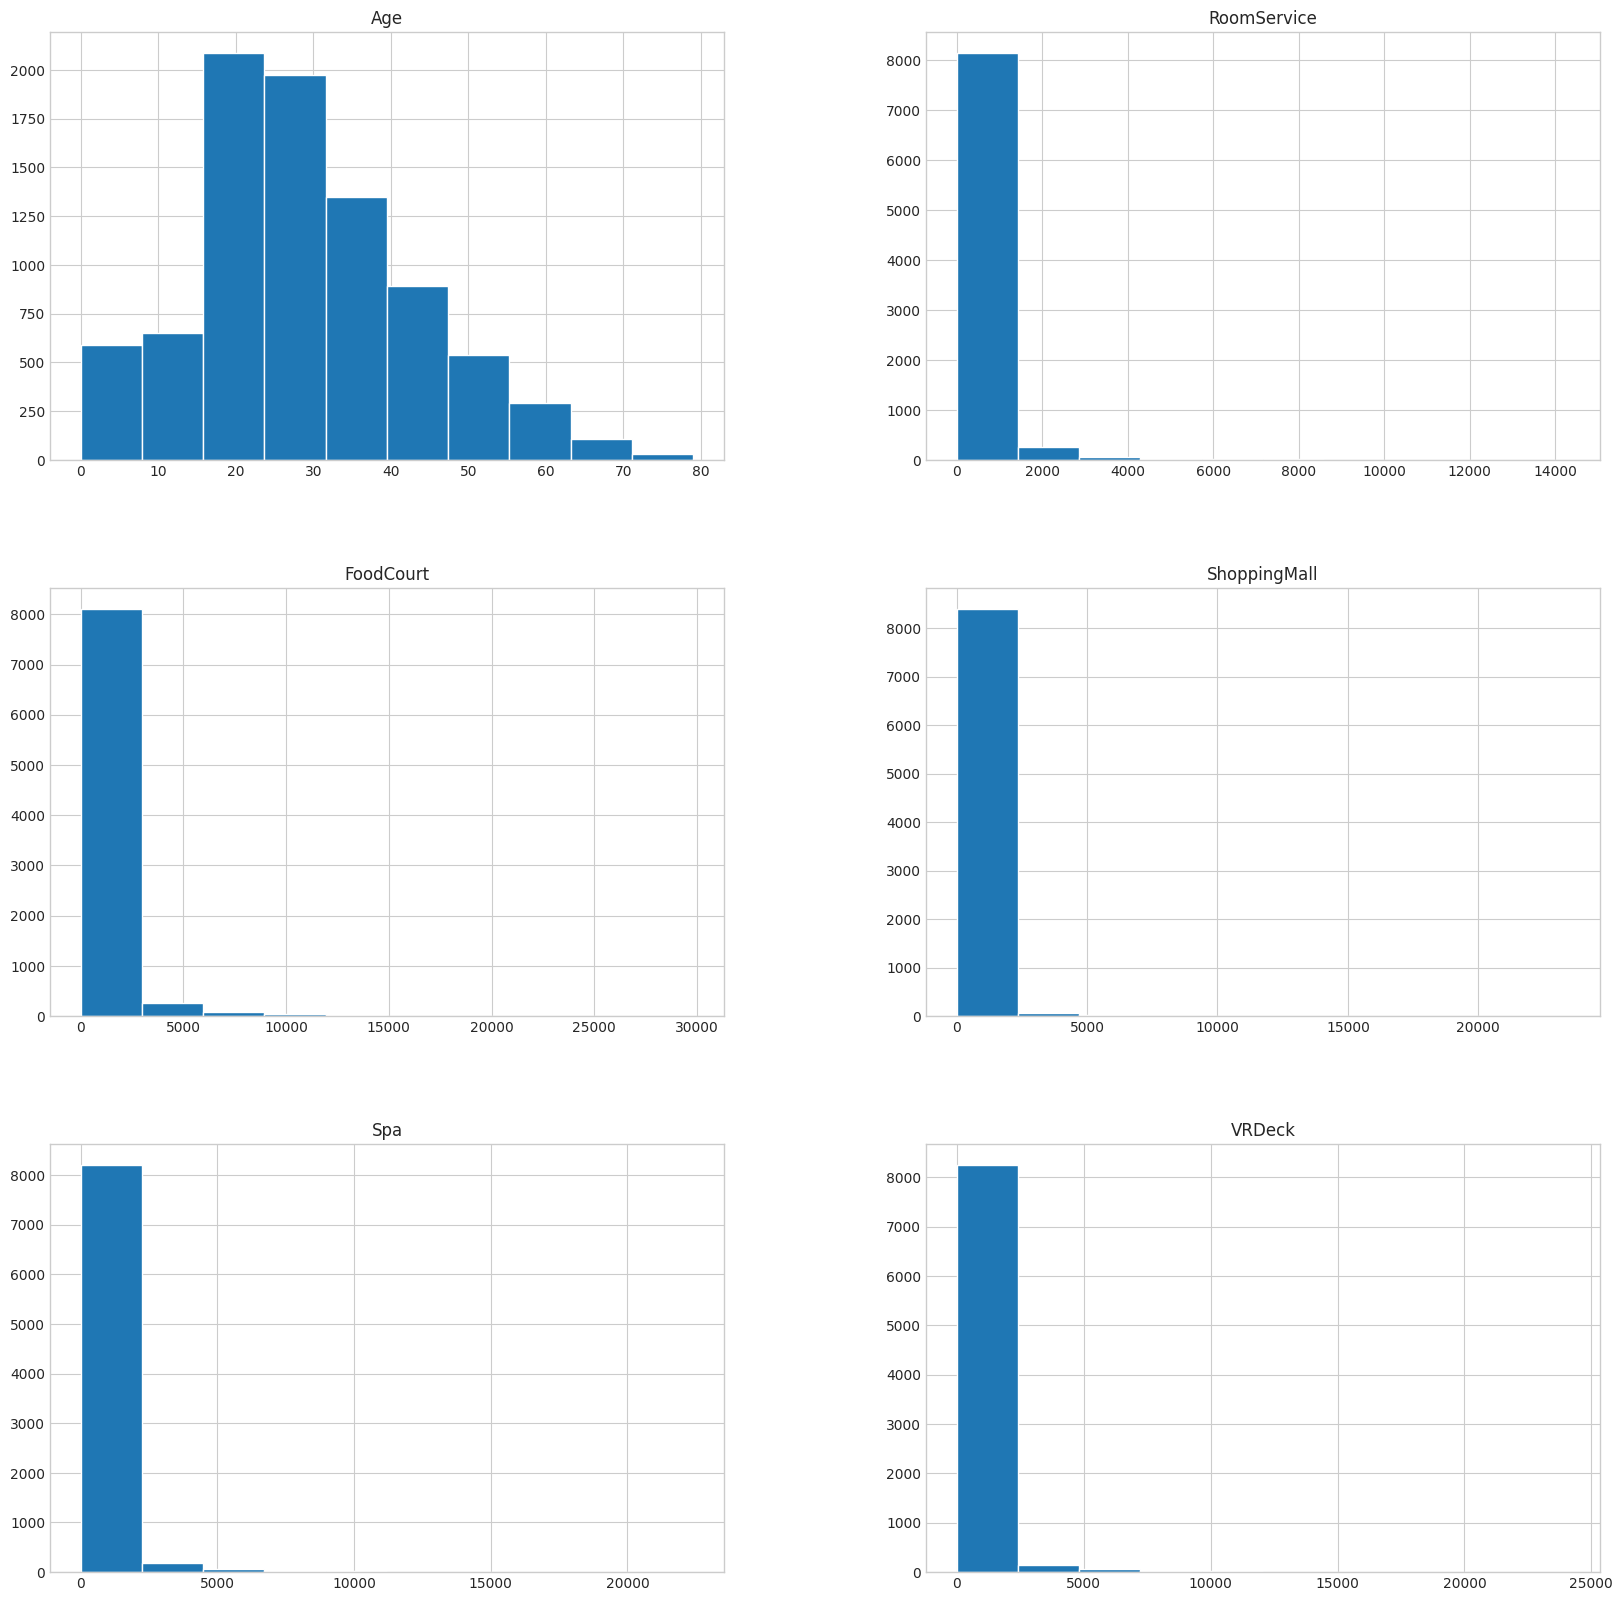

In [14]:
# Plot all variables' data distributions with histograms
titanic_eda.hist(figsize=(20, 20))
plt.show()

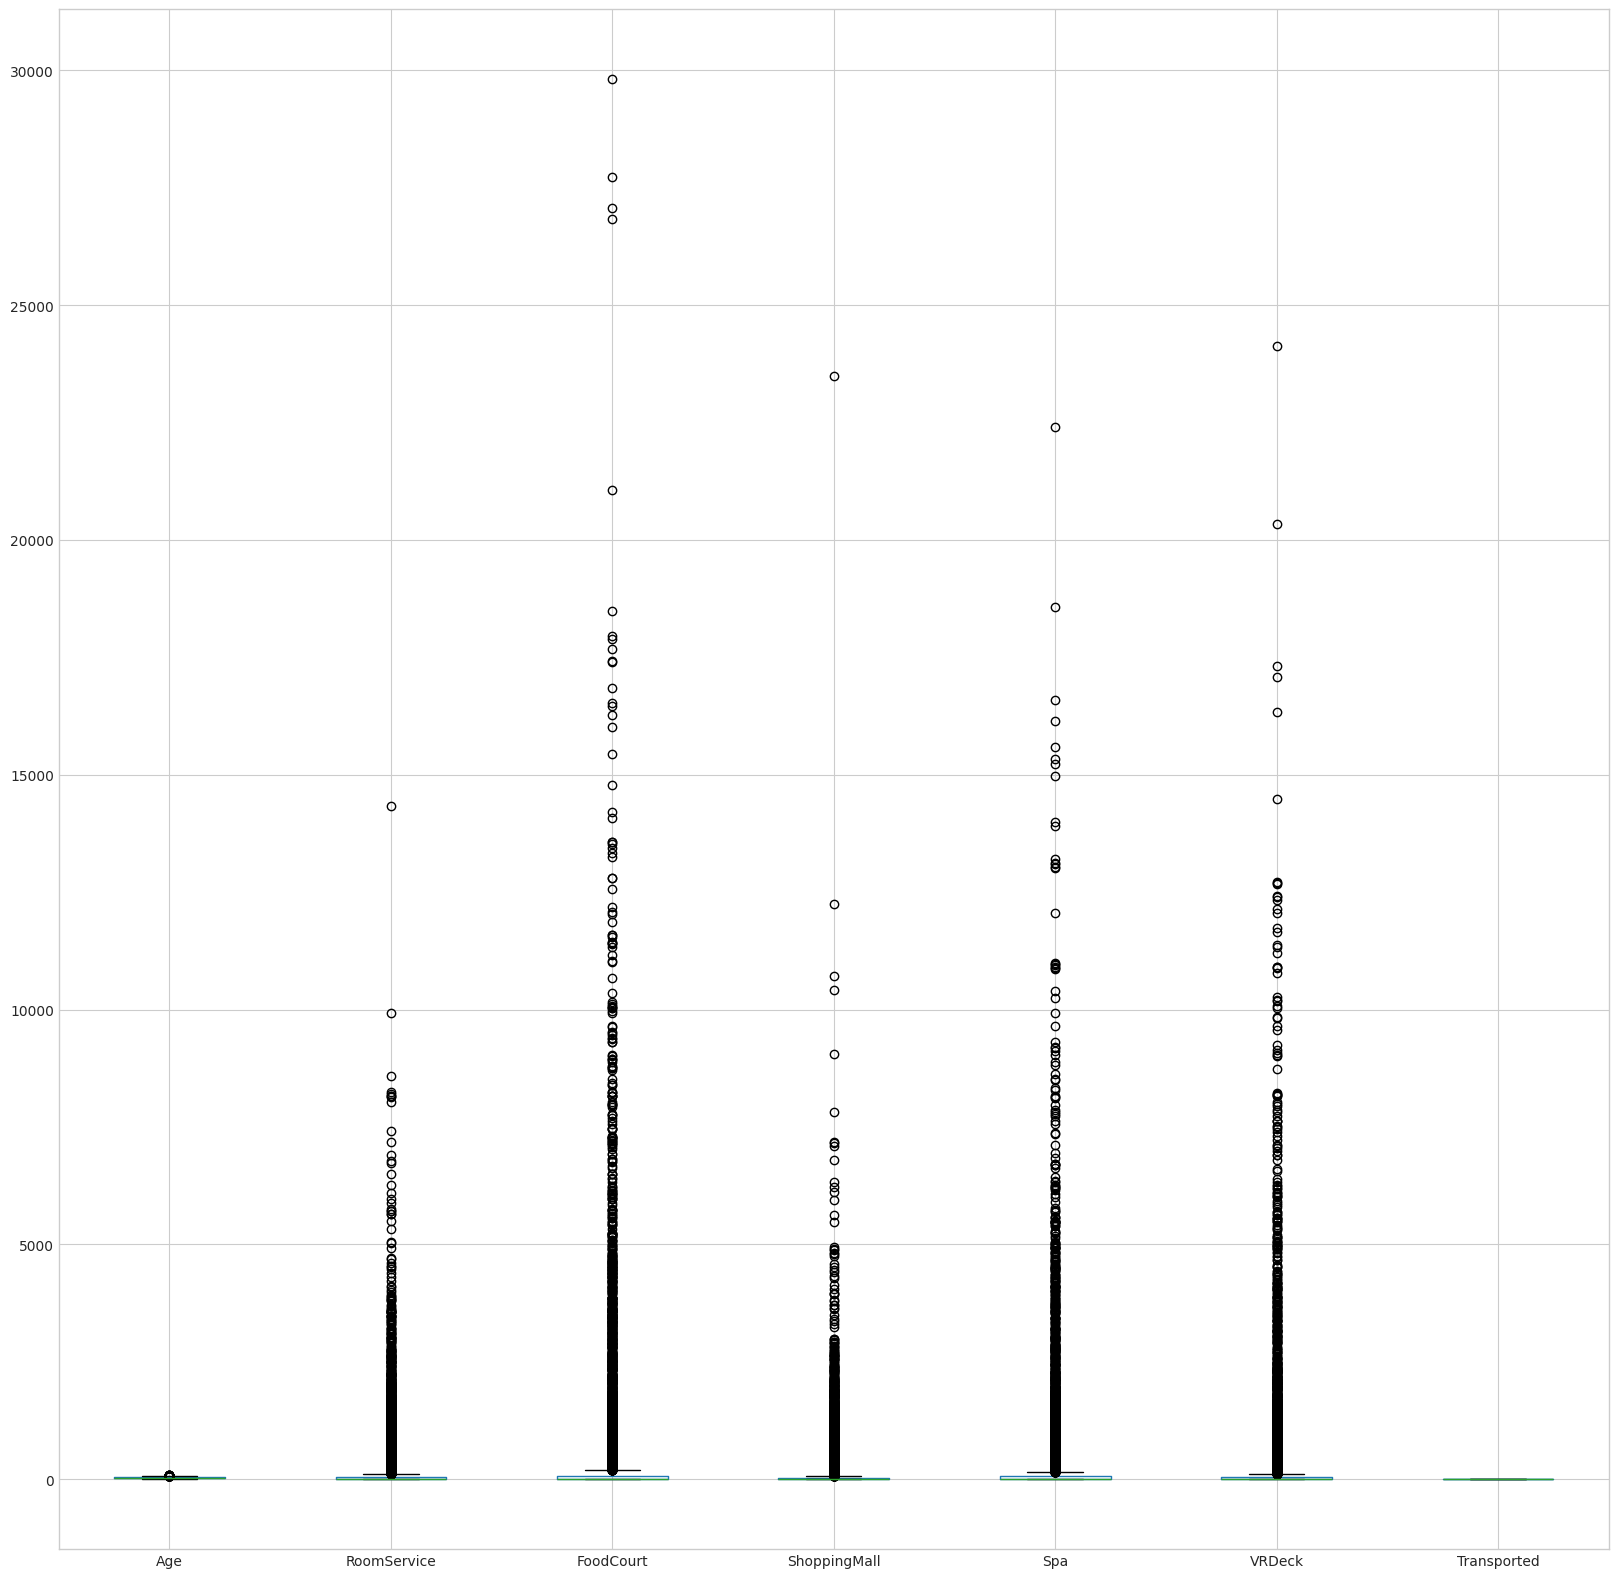

In [15]:
# Checking with box plots
titanic_eda.boxplot(figsize=(20, 20))
plt.show()

In [16]:
# Dropping Name column since not using
titanic_eda.drop('Name',axis=1,inplace=True)

In [17]:
# Dropping rows with empty values for columns for EDA
titanic_eda.dropna(inplace=True)

In [18]:
titanic_eda.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,6764.000000,6764.000000,6764.000000,6764.000000,6764.000000,6764.000000
mean,28.897398,224.415582,479.736251,180.495713,313.856298,304.565937
std,14.529563,648.056361,1676.922138,638.032157,1138.989471,1126.895655
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,51.000000,82.000000,30.250000,66.250000,52.000000
max,79.000000,9920.000000,29813.000000,23492.000000,22408.000000,20336.000000


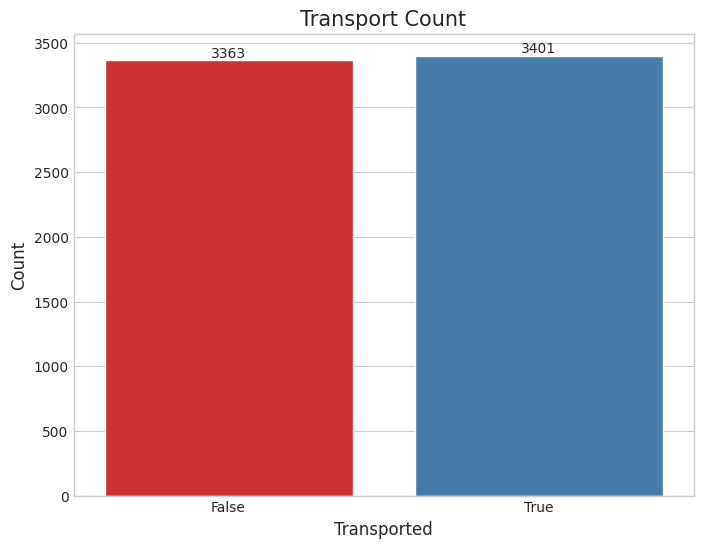

In [19]:
# Checking target variable
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transport Count', fontsize=15)
plt.xlabel('Transported', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

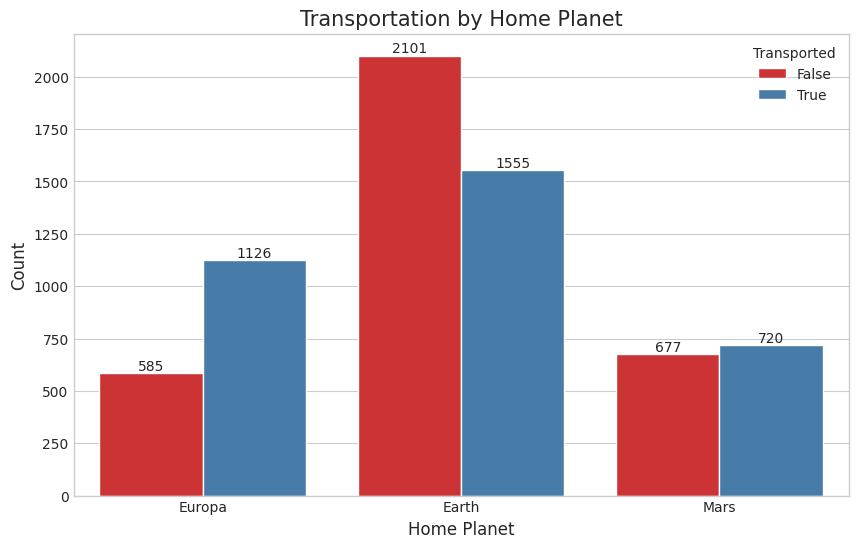

In [20]:
# Transportation by Home Planet
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='HomePlanet', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Home Planet', fontsize=15)
plt.xlabel('Home Planet', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

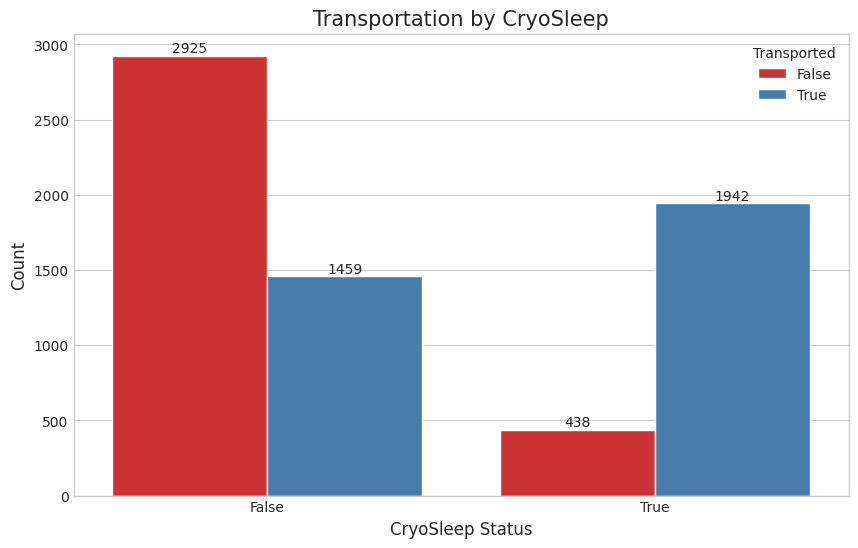

In [21]:
# Transportation by CryoSleep
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='CryoSleep', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by CryoSleep', fontsize=15)
plt.xlabel('CryoSleep Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [22]:
# Data Transformation for Cabin variable
newcabin = titanic_eda['Cabin'].str.split('/',expand=True)
titanic_eda['Deck']=newcabin[0]
titanic_eda['Side']=newcabin[2]

display(titanic_eda)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,A,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,G,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,G,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,E,S


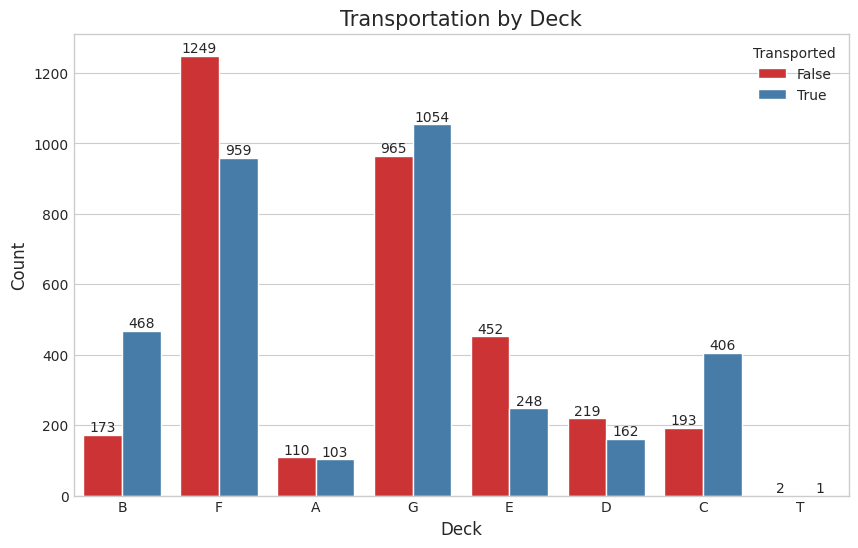

In [23]:
# Transportation by Deck
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Deck', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Deck', fontsize=15)
plt.xlabel('Deck', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

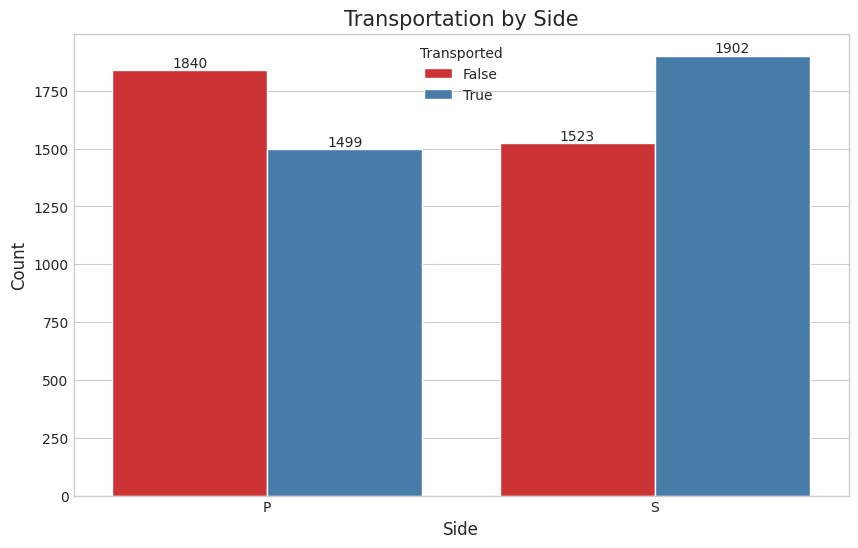

In [24]:
# Transportation by Side
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Side', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Side', fontsize=15)
plt.xlabel('Side', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

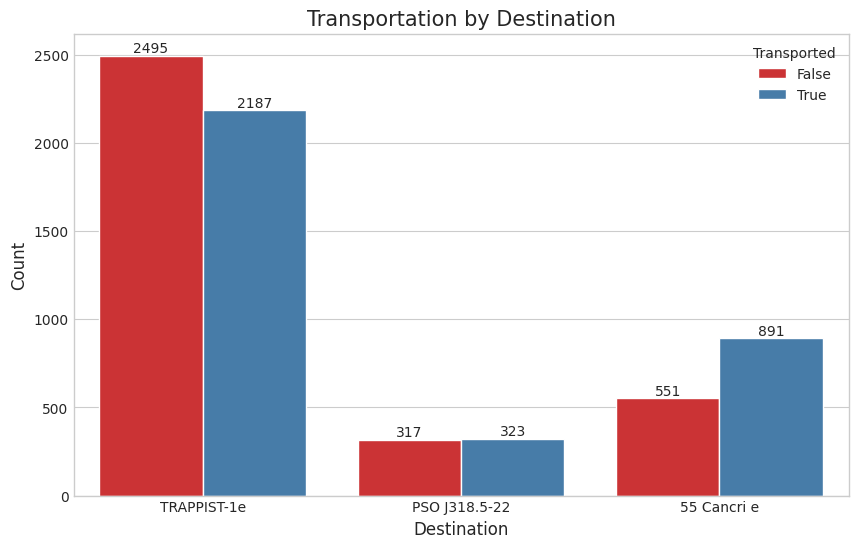

In [25]:
# Transportation by Destination
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Destination', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Destination', fontsize=15)
plt.xlabel('Destination', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

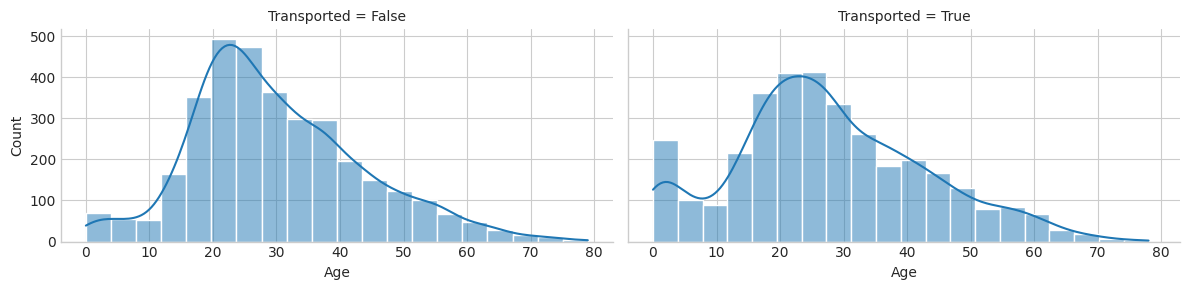

In [26]:
# Age Distrubution by Transportation
g = sns.FacetGrid(titanic_eda, col= 'Transported',aspect=2)
g.map(sns.histplot, 'Age', bins=20, kde=True)
plt.show()

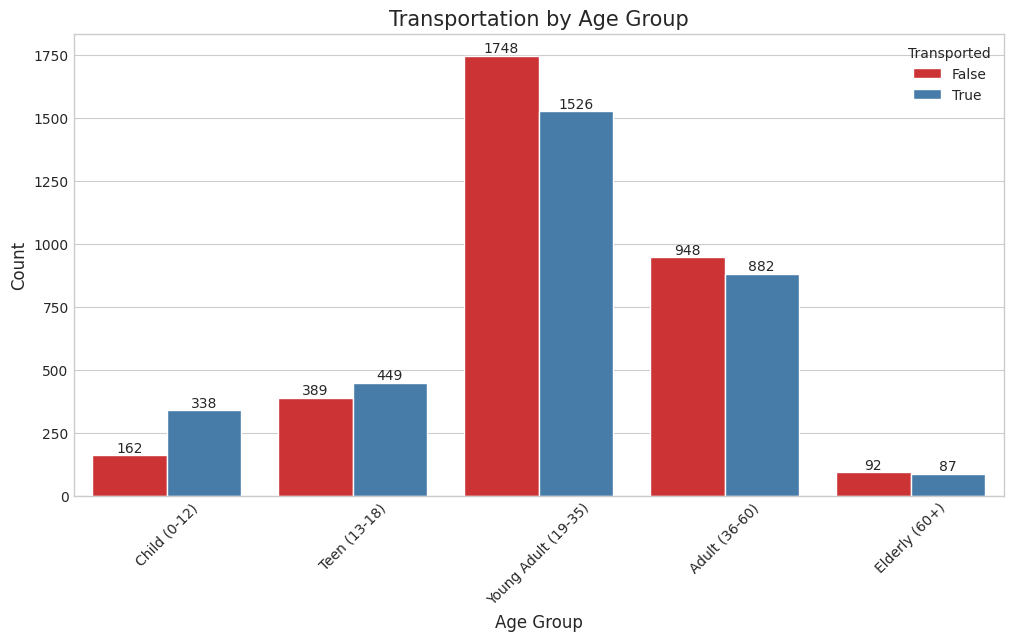

In [27]:
# Create age groups for better visualization
titanic_eda['AgeGroup'] = pd.cut(titanic_eda['Age'], bins=[0, 12, 18, 35, 60, 100],
                            labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)',
                                   'Adult (36-60)', 'Elderly (60+)'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='AgeGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Age Group', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

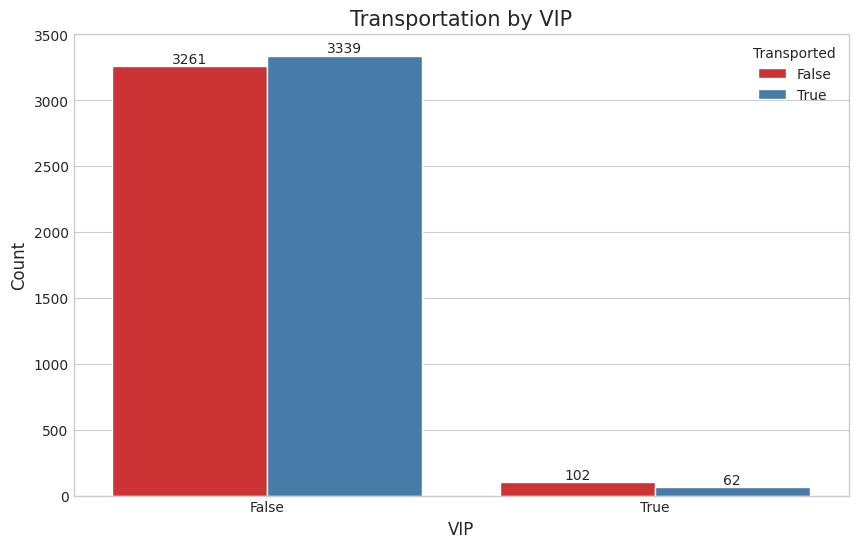

In [28]:
# Transportation by VIP
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='VIP', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by VIP', fontsize=15)
plt.xlabel('VIP', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [29]:
# Converting entertainment columns to integers
entertainment = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
titanic_eda[entertainment] = titanic_eda[entertainment].astype(int)

# Calculating total spend of passengers
titanic_eda['TotalSpend'] = titanic_eda[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)
display(titanic_eda)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Side,AgeGroup,TotalSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0,0,0,0,0,False,B,P,Adult (36-60),0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109,9,25,549,44,True,F,S,Young Adult (19-35),736
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43,3576,0,6715,49,False,A,S,Adult (36-60),10383
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0,1283,371,3329,193,False,A,S,Young Adult (19-35),5176
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303,70,151,565,2,True,F,S,Teen (13-18),1091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0,6819,0,1643,74,False,A,P,Adult (36-60),8536
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0,0,0,0,0,False,G,S,Teen (13-18),0
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0,0,1872,1,0,True,G,S,Young Adult (19-35),1873
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0,1049,0,353,3235,False,E,S,Young Adult (19-35),4637


In [30]:
titanic_eda['RoomService'].describe()

,RoomService
count,6764.000000
mean,224.415582
std,648.056361
min,0.000000
25%,0.000000
50%,0.000000
75%,51.000000
max,9920.000000


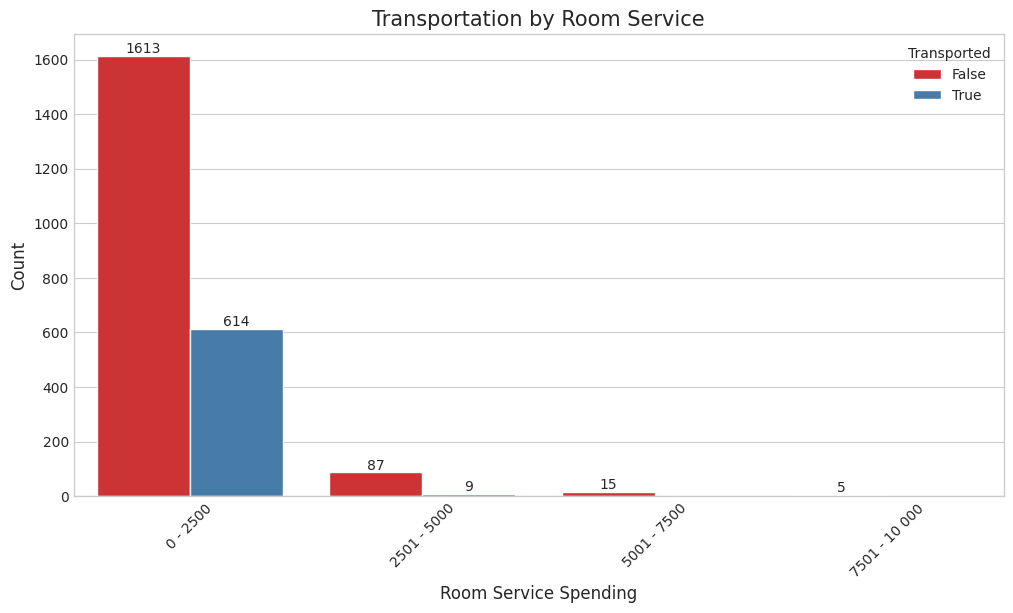

In [31]:
# Transportation by Room Service spending
titanic_eda['RoomServiceGroup'] = pd.cut(titanic_eda['RoomService'], bins=[0, 2500, 5000, 7500, 10000],
                                   labels=['0 - 2500', '2501 - 5000', '5001 - 7500', '7501 - 10 000'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='RoomServiceGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Room Service', fontsize=15)
plt.xlabel('Room Service Spending', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [32]:
titanic_eda['FoodCourt'].describe()

,FoodCourt
count,6764.000000
mean,479.736251
std,1676.922138
min,0.000000
25%,0.000000
50%,0.000000
75%,82.000000
max,29813.000000


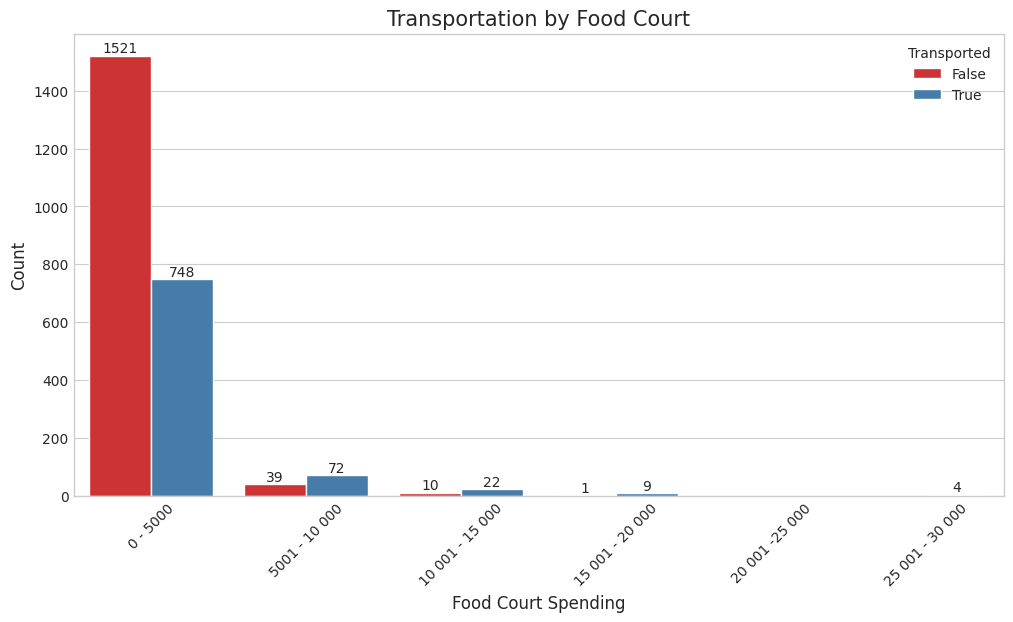

In [33]:
# Transportation by Food Court spending
titanic_eda['FoodCourtGroup'] = pd.cut(titanic_eda['FoodCourt'], bins=[0, 5000, 10000, 15000, 20000, 25000, 30000],
                                   labels=['0 - 5000', '5001 - 10 000', '10 001 - 15 000', '15 001 - 20 000', '20 001 -25 000',
                                   '25 001 - 30 000'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='FoodCourtGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Food Court', fontsize=15)
plt.xlabel('Food Court Spending', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [34]:
titanic_eda['ShoppingMall'].describe()

,ShoppingMall
count,6764.000000
mean,180.495713
std,638.032157
min,0.000000
25%,0.000000
50%,0.000000
75%,30.250000
max,23492.000000


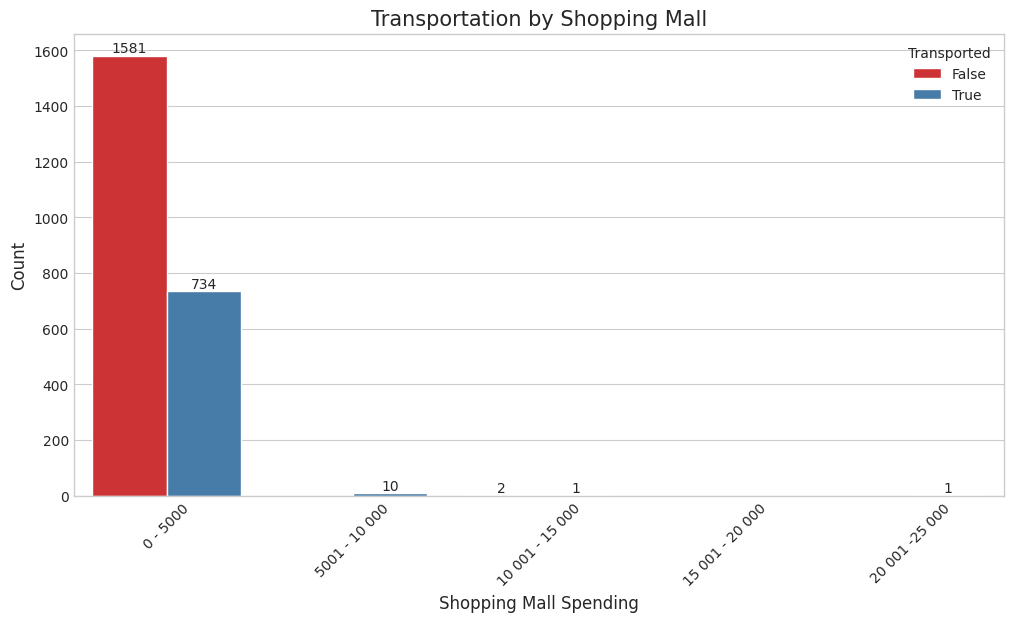

In [35]:
# Transportation by Shopping Mall spending
titanic_eda['ShoppingMallGroup'] = pd.cut(titanic_eda['ShoppingMall'], bins=[0, 5000, 10000, 15000, 20000, 25000],
                                   labels=['0 - 5000', '5001 - 10 000', '10 001 - 15 000', '15 001 - 20 000', '20 001 -25 000'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='ShoppingMallGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Shopping Mall', fontsize=15)
plt.xlabel('Shopping Mall Spending', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [36]:
titanic_eda['Spa'].describe()

,Spa
count,6764.000000
mean,313.856298
std,1138.989471
min,0.000000
25%,0.000000
50%,0.000000
75%,66.250000
max,22408.000000


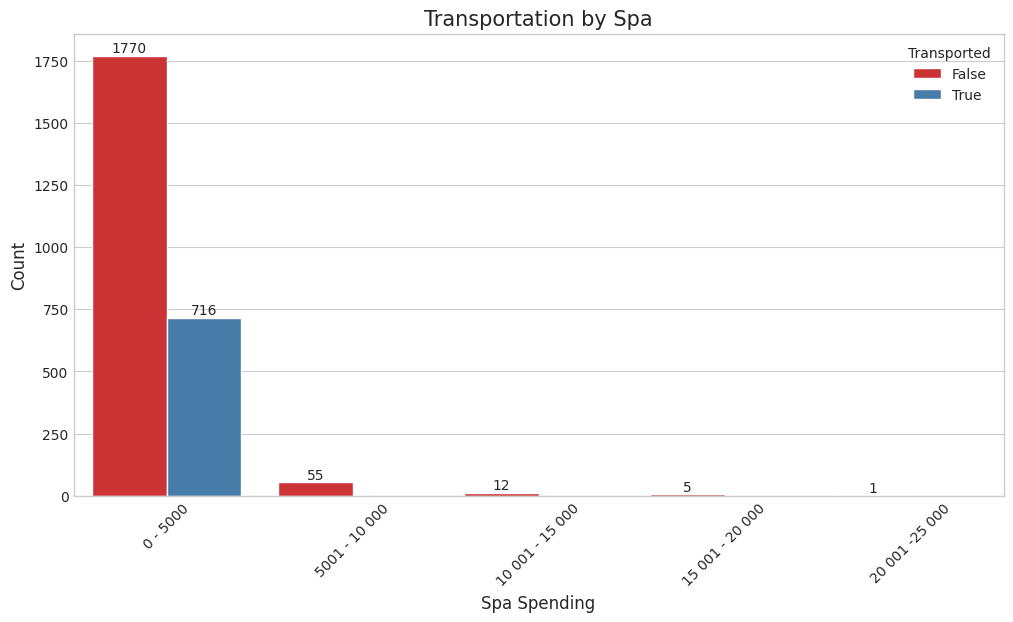

In [37]:
# Transportation by Spa spending
titanic_eda['SpaGroup'] = pd.cut(titanic_eda['Spa'], bins=[0, 5000, 10000, 15000, 20000, 25000],
                                   labels=['0 - 5000', '5001 - 10 000', '10 001 - 15 000', '15 001 - 20 000', '20 001 -25 000'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='SpaGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Spa', fontsize=15)
plt.xlabel('Spa Spending', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [38]:
titanic_eda['VRDeck'].describe()

,VRDeck
count,6764.000000
mean,304.565937
std,1126.895655
min,0.000000
25%,0.000000
50%,0.000000
75%,52.000000
max,20336.000000


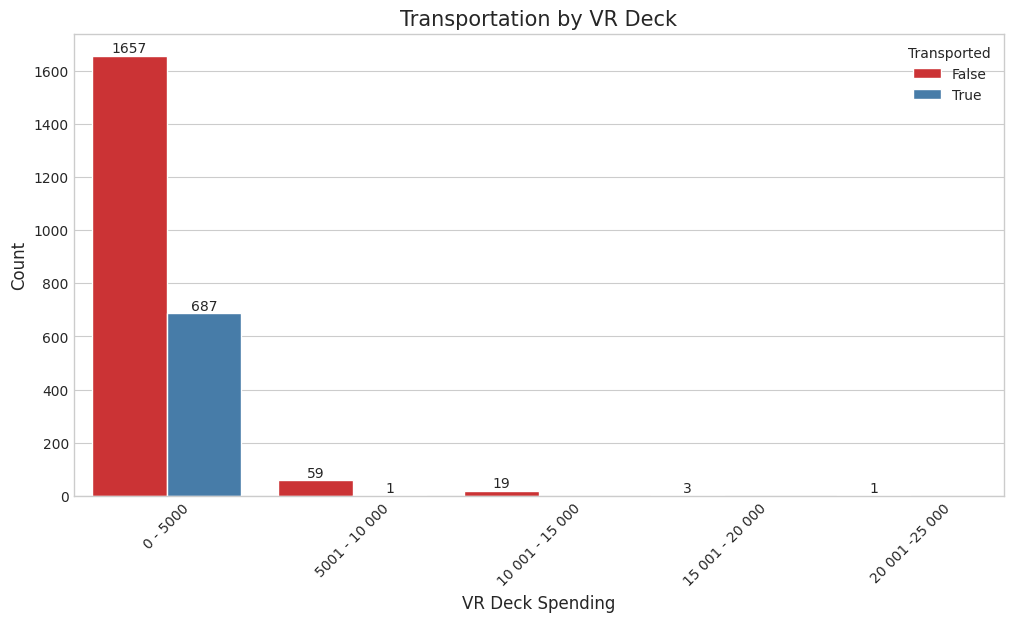

In [39]:
# Transportation by VR Deck spending
titanic_eda['VRDeckGroup'] = pd.cut(titanic_eda['VRDeck'], bins=[0, 5000, 10000, 15000, 20000, 25000],
                                   labels=['0 - 5000', '5001 - 10 000', '10 001 - 15 000', '15 001 - 20 000', '20 001 -25 000'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='VRDeckGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by VR Deck', fontsize=15)
plt.xlabel('VR Deck Spending', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [40]:
titanic_eda['TotalSpend'].describe()

,TotalSpend
count,6764.000000
mean,1503.069781
std,2874.164516
min,0.000000
25%,0.000000
50%,741.000000
75%,1515.000000
max,35987.000000


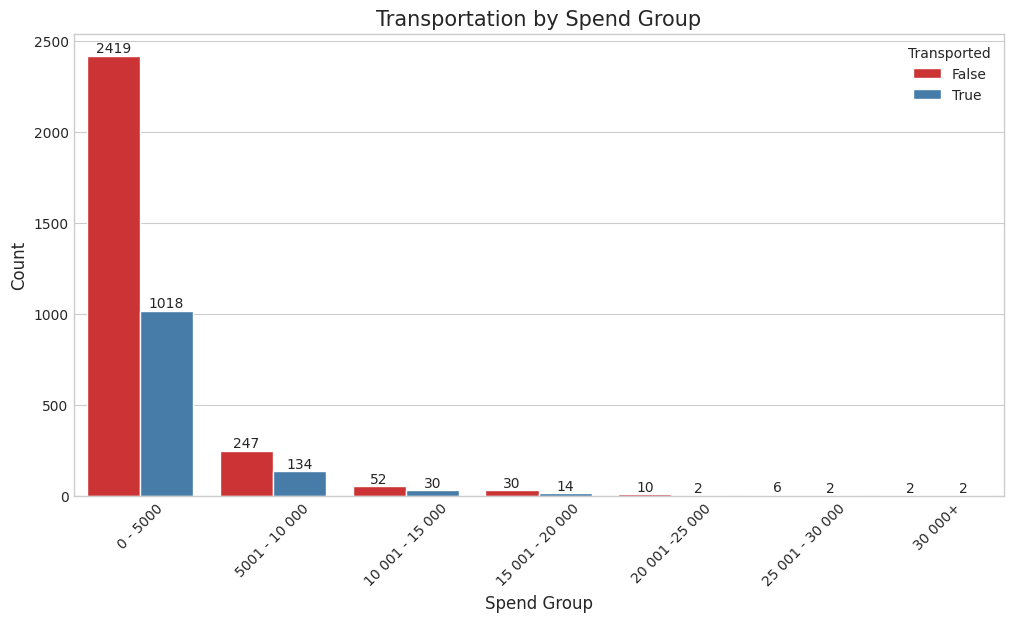

In [41]:
# Create spend groups for better visualization
titanic_eda['SpendGroup'] = pd.cut(titanic_eda['TotalSpend'], bins=[0, 5000, 10000, 15000, 20000, 25000, 30000, 35987],
                                   labels=['0 - 5000', '5001 - 10 000', '10 001 - 15 000', '15 001 - 20 000', '20 001 -25 000',
                                   '25 001 - 30 000', '30 000+'])

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='SpendGroup', hue='Transported', data=titanic_eda, palette='Set1')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Transportation by Spend Group', fontsize=15)
plt.xlabel('Spend Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Multi-variate Analysis

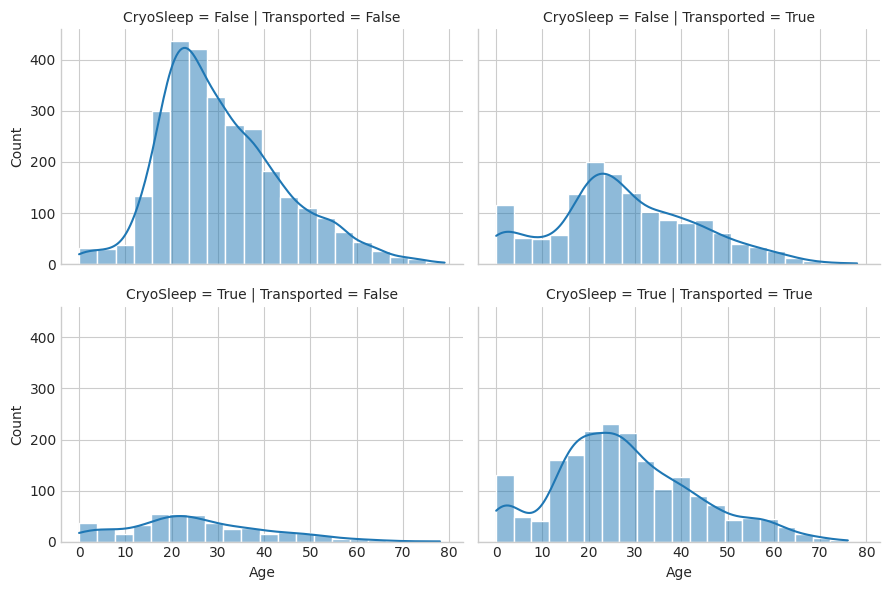

In [42]:
grid = sns.FacetGrid(titanic_eda, col='Transported', row='CryoSleep', aspect=1.5)
grid.map(sns.histplot, 'Age', alpha=.5, bins=20, kde=True)
plt.show()

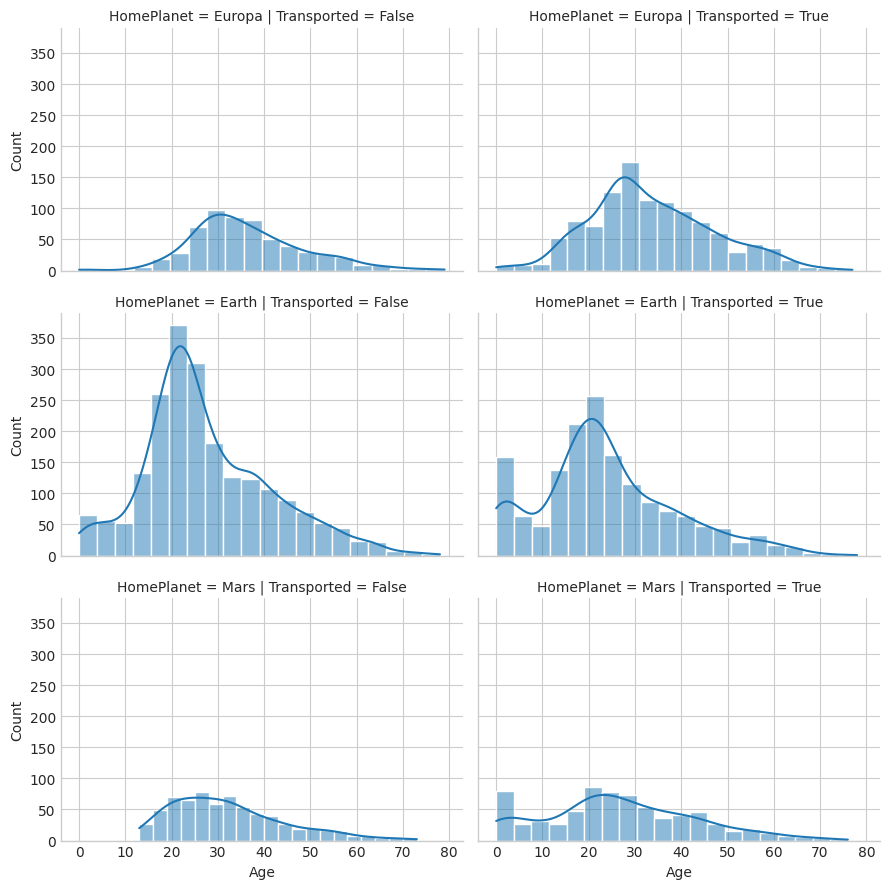

In [43]:
grid = sns.FacetGrid(titanic_eda, col='Transported', row='HomePlanet', aspect=1.5)
grid.map(sns.histplot, 'Age', alpha=.5, bins=20, kde=True)
plt.show()

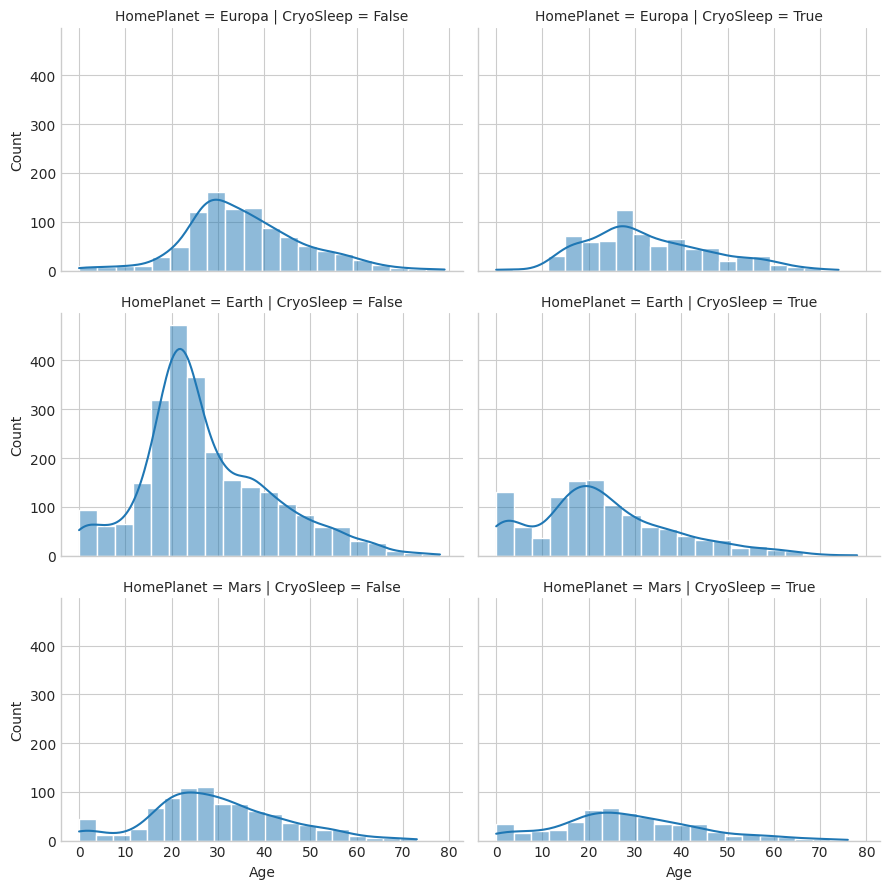

In [44]:
grid = sns.FacetGrid(titanic_eda, col='CryoSleep', row='HomePlanet', aspect=1.5)
grid.map(sns.histplot, 'Age', alpha=.5, bins=20, kde=True)
plt.show()

# Correlation Analysis

In [45]:
# Display current state of dataset
titanic_eda

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Deck,Side,AgeGroup,TotalSpend,RoomServiceGroup,FoodCourtGroup,ShoppingMallGroup,SpaGroup,VRDeckGroup,SpendGroup
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0,0,0,...,B,P,Adult (36-60),0,NaN,NaN,NaN,NaN,NaN,NaN
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109,9,25,...,F,S,Young Adult (19-35),736,0 - 2500,0 - 5000,0 - 5000,0 - 5000,0 - 5000,0 - 5000
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43,3576,0,...,A,S,Adult (36-60),10383,0 - 2500,0 - 5000,NaN,5001 - 10 000,0 - 5000,10 001 - 15 000
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0,1283,371,...,A,S,Young Adult (19-35),5176,NaN,0 - 5000,0 - 5000,0 - 5000,0 - 5000,5001 - 10 000
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303,70,151,...,F,S,Teen (13-18),1091,0 - 2500,0 - 5000,0 - 5000,0 - 5000,0 - 5000,0 - 5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0,6819,0,...,A,P,Adult (36-60),8536,NaN,5001 - 10 000,NaN,0 - 5000,0 - 5000,5001 - 10 000
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0,0,0,...,G,S,Teen (13-18),0,NaN,NaN,NaN,NaN,NaN,NaN
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0,0,1872,...,G,S,Young Adult (19-35),1873,NaN,NaN,0 - 5000,0 - 5000,NaN,0 - 5000
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0,1049,0,...,E,S,Young Adult (19-35),4637,NaN,0 - 5000,NaN,0 - 5000,0 - 5000,0 - 5000


In [46]:
# Convert the Transported variable to a number
titanic_eda['Transported'] = titanic_eda['Transported'].replace({
    'False':'0',
    'True':'1'
})

# Convert the Transported variable's data type to integer type
titanic_eda['Transported'] = titanic_eda['Transported'].astype(int)

In [47]:
# Convert the Side variable to a number
titanic_eda['Side'] = titanic_eda['Side'].replace({
    'P':'0',
    'S':'1'
})

# Convert the Side variable's data type to integer type
titanic_eda['Side'] = titanic_eda['Side'].astype(int)

In [48]:
# Convert the CryoSleep variable to a number
titanic_eda['CryoSleep'] = titanic_eda['CryoSleep'].replace({
    'False':'0',
    'True':'1'
})

# Convert the CryoSleep variable's data type to integer type
titanic_eda['CryoSleep'] = titanic_eda['CryoSleep'].astype(int)

In [49]:
# One-hot encode the HomePlanet variable
titanic_eda_encoded = pd.get_dummies(titanic_eda, columns=['HomePlanet'], dtype=int)

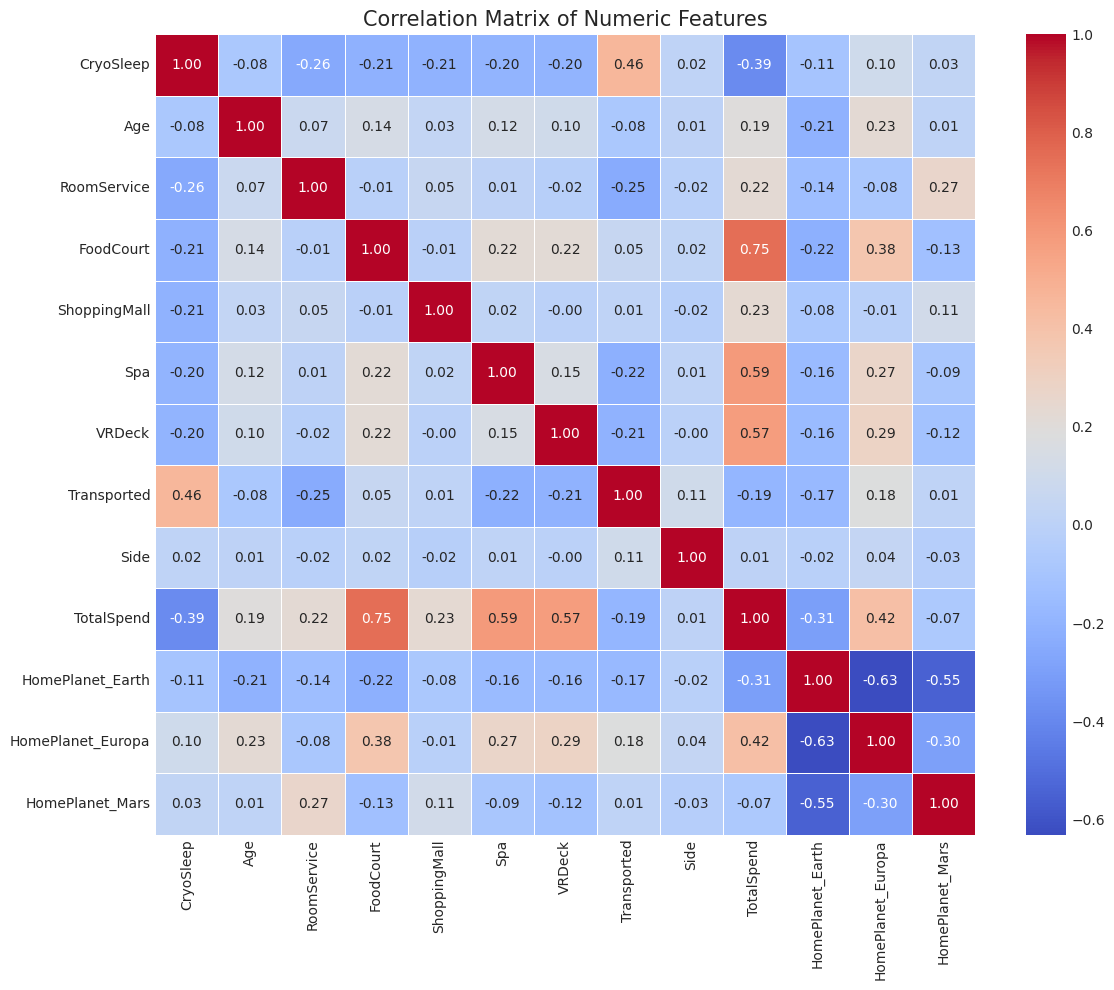

In [50]:
# Select numeric columns
numeric_cols = titanic_eda_encoded.select_dtypes(include=['float64', 'int64']).columns

# Create correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = titanic_eda_encoded[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=15)
plt.tight_layout()
plt.show()

# Data Preprocessing for Modelling

In [134]:
# Create a data copy
titanic_copy = titanic.copy()

In [135]:
# One-hot encode the HomePlanet variable
titanic_encoded = pd.get_dummies(titanic_copy, columns=['HomePlanet'], dtype=int)

In [136]:
# Create a data copy for modelling
titanic_model = titanic_encoded.copy()

In [137]:
# Drop unnecessary columns for modelling
titanic_model.drop(['PassengerId','Name','Age','Destination','Cabin','VIP','FoodCourt','ShoppingMall'], axis=1, inplace = True)

In [138]:
# Checking missing values
titanic_model.isnull().sum()

,0
CryoSleep,217
RoomService,181
Spa,183
VRDeck,188
Transported,0
HomePlanet_Earth,0
HomePlanet_Europa,0
HomePlanet_Mars,0


In [139]:
# Remove missing values
titanic_model_cleaned = titanic_model.dropna()

In [140]:
# Convert the Transported variable to a number
titanic_model_cleaned['Transported'] = titanic_model_cleaned['Transported'].replace({
    'False':'0',
    'True':'1'
})

# Convert the Transported variable's data type to integer type
titanic_model_cleaned['Transported'] = titanic_model_cleaned['Transported'].astype(int)

In [141]:
# Convert the CryoSleep variable to a number
titanic_model_cleaned['CryoSleep'] = titanic_model_cleaned['CryoSleep'].replace({
    'False':'0',
    'True':'1'
})

# Convert the CryoSleep variable's data type to integer type
titanic_model_cleaned['CryoSleep'] = titanic_model_cleaned['CryoSleep'].astype(int)

In [142]:
# Convert entertainment columns to integers
entertainment = ['RoomService','Spa','VRDeck']
titanic_model_cleaned[entertainment] = titanic_model_cleaned[entertainment].astype(int)

In [143]:
# Display final set of data for modelling
titanic_model_cleaned

,CryoSleep,RoomService,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars
0,0,0,0,0,0,0,1,0
1,0,109,549,44,1,1,0,0
2,0,43,6715,49,0,0,1,0
3,0,0,3329,193,0,0,1,0
4,0,303,565,2,1,1,0,0
...,...,...,...,...,...,...,...,...
8688,0,0,1643,74,0,0,1,0
8689,1,0,0,0,0,1,0,0
8690,0,0,1,0,1,1,0,0
8691,0,0,353,3235,0,0,1,0


# Data Modelling

In [144]:
# Define features and target
X = titanic_model_cleaned.drop(['Transported'], axis=1)
y = titanic_model_cleaned['Transported']

In [145]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Print sample sizes of training set and testing set
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 5959 samples
Testing set size: 1987 samples


In [146]:
# Print the list of variables in the feature and target
print("Input Variables:", [i for i in X_train.columns])
print("Target Variable:", y_train.name)

Input Variables: ['CryoSleep', 'RoomService', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']
Target Variable: Transported


In [147]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Create the grid search object
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          param_grid=param_grid,
                          cv=5,
                          scoring='accuracy',
                          verbose=1,
                          n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validation accuracy: 0.7837


In [148]:
# Test set performance with best model
best_dt_model = grid_search.best_estimator_
best_y_pred = best_dt_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_y_pred)
print(f"Best model test accuracy: {best_accuracy:.4f}")

Best model test accuracy: 0.7866


In [149]:
# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=7,criterion='gini', min_samples_leaf=8, min_samples_split=2)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=8, random_state=42)

In [150]:
# Make predictions
y_pred = dt_model.predict(X_test)

In [151]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7932


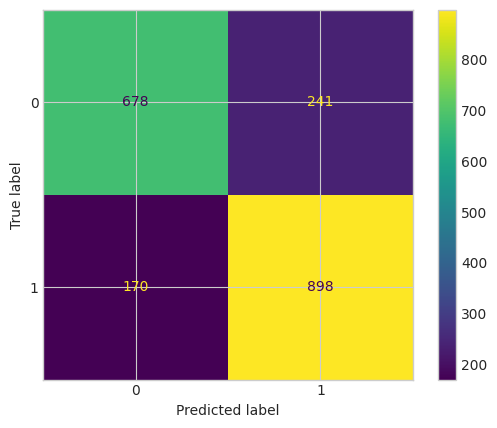

In [152]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_dt_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_dt_model.classes_)
disp.plot()
plt.show()

In [153]:
# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       919
           1       0.79      0.84      0.81      1068

    accuracy                           0.79      1987
   macro avg       0.79      0.79      0.79      1987
weighted avg       0.79      0.79      0.79      1987



# Data preprocessing of testing data

In [186]:
# Loading dataset
testing = pd.read_csv('test.csv')
display(testing)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [187]:
# Store PassengerId
results = testing[['PassengerId']]

In [188]:
# Create a copy of testing dataset
testing_copy = testing.copy()

In [189]:
# One-hot encode the HomePlanet variable
testing_encoded = pd.get_dummies(testing_copy, columns=['HomePlanet'], dtype=int)

In [190]:
# Create a data copy for modelling
testing_model = testing_encoded.copy()

In [191]:
# Drop unnecessary columns for modelling
testing_model.drop(['PassengerId','Name','Age','Destination','Cabin','VIP','FoodCourt','ShoppingMall'], axis=1, inplace = True)

In [192]:
# Check missing values
testing_model.isnull().sum()

,0
CryoSleep,93
RoomService,82
Spa,101
VRDeck,80
HomePlanet_Earth,0
HomePlanet_Europa,0
HomePlanet_Mars,0


In [193]:
# Fill in missing values in the CryoSleep variable
testing_model['CryoSleep'] = testing_model['CryoSleep'].fillna(testing_model['CryoSleep'].mode()[0])

In [194]:
# Fill in missing values in the RoomService variable
testing_model['RoomService'] = testing_model['RoomService'].fillna(testing_model['RoomService'].median())

In [195]:
# Fill in missing values in the Spa variable
testing_model['Spa'] = testing_model['Spa'].fillna(testing_model['Spa'].median())

In [196]:
# Fill in missing values in the VRDeck variable
testing_model['VRDeck'] = testing_model['VRDeck'].fillna(testing_model['VRDeck'].median())

In [197]:
# Check missing values
testing_model.isnull().sum()

,0
CryoSleep,0
RoomService,0
Spa,0
VRDeck,0
HomePlanet_Earth,0
HomePlanet_Europa,0
HomePlanet_Mars,0


In [198]:
# Convert the CryoSleep variable to a number
testing_model['CryoSleep'] = testing_model['CryoSleep'].replace({
    'False':'0',
    'True':'1'
})

# Convert the CryoSleep variable's data type to integer type
testing_model['CryoSleep'] = testing_model['CryoSleep'].astype(int)

In [199]:
# Convert entertainment columns to integers
entertainment = ['RoomService','Spa','VRDeck']
testing_model[entertainment] = testing_model[entertainment].astype(int)

# Test Data Modelling

In [200]:
# Define features and target
X = testing_model

In [201]:
# Print the list of variables in the feature and target
print("Input Variables:", [i for i in X.columns])

Input Variables: ['CryoSleep', 'RoomService', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


In [202]:
# Make predictions
y_pred = dt_model.predict(X)

In [203]:
results['Transported'] = y_pred

In [204]:
# Convert the Transported variable's data type to boolean type
results['Transported'] = results['Transported'].astype(bool)

In [205]:
# Check results
results

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [206]:
# Export results into a csv file
results.to_csv('results.csv', index=False, header=True)